In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [5]:
image_size = 256
batch_size = 32
channels = 3

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../MRI_DATASET/Training",
    shuffle=True,
    image_size = (image_size,image_size),
    batch_size = batch_size

)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "../MRI_DATASET/Testing",
    shuffle=True,
    image_size = (image_size,image_size),
    batch_size = batch_size

)

Found 6985 files belonging to 4 classes.
Found 2063 files belonging to 4 classes.


In [7]:
class_names = train_ds.class_names
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

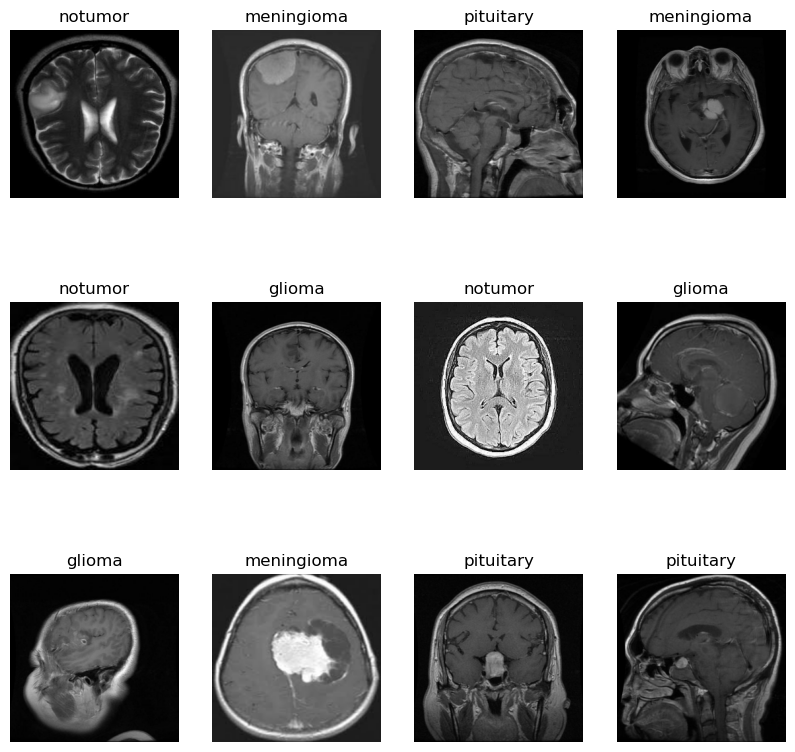

In [8]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in train_ds.take(1):
    for i in range (12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [9]:
# Split the training dataset into training and validation sets
train_size = int(0.9 * len(train_ds))
train_img = train_ds.take(train_size)
val_ds = train_ds.skip(train_size)

In [10]:
train_img = train_img.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_img = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(image_size,image_size),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [13]:
input_shape = (batch_size,image_size,image_size,channels)
n_classes = 4

In [14]:
from tensorflow.keras import layers, models

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(96, (11, 11), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=input_shape)


In [15]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d (Conv2D)             (32, 246, 246, 96)        34944     
                                                                 
 max_pooling2d (MaxPooling2  (32, 123, 123, 96)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (32, 121, 121, 64)        55360     
                                                                 
 max_pooling2d_1 (MaxPoolin  (32, 60, 60, 64)          0         
 g2D)                                                 

In [16]:
model.compile(
    optimizer='adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

In [17]:
history = model.fit(
    train_img,
    epochs=20,
    batch_size=batch_size,
    verbose=1,
    validation_data=val_img

)

Epoch 1/20


 20/197 [==>...........................] - ETA: 20:58 - loss: 1.2893 - accuracy: 0.3812

KeyboardInterrupt: 

In [ ]:
# Evaluate the model on the test set
scores = model.evaluate(test_ds)
print(f'Test Accuracy: {scores[1]*100:.2f}%')

In [ ]:
scores

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
ephocs = 20

In [ ]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(ephocs),acc,label = "Training Accuracy")
plt.plot(range(ephocs),val_acc,label = "Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(ephocs),loss,label = "Training Loss")
plt.plot(range(ephocs),val_loss,label = "Validation Loss")
plt.legend(loc='lower right')
plt.title("Training and Validation loss")

plt.show()

In [ ]:
for image_batch,label_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    print("First image to Predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print(class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model,img):
    img_array = tf.keras.preprocessing.image.img_to_array(image[i].numpy())
    img_array = tf.expand_dims(img_array,0)
    
    prediction = model.predict(img_array)
    
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = round(100 * (np.max(prediction[0])),2)
    return predicted_class, confidence

In [ ]:
plt.figure(figsize=(15,15))
for image, labels in test_ds.take(1):
    for i in range (9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        
        predicted_class, confidence = predict(model,image[i].numpy())
        actual_class = class_names[labels[i]]
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis('off')
        

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# Plot Training and Validation Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
# Generate Confusion Matrix
y_true = []
y_pred = []
for image_batch, label_batch in test_ds:
    y_true.extend(label_batch.numpy())
    predictions = model.predict(image_batch)
    y_pred.extend(np.argmax(predictions, axis=1))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print('Classification Report:')
print(report)

In [ ]:
# Example Predictions
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction[0])]
    confidence = round(100 * (np.max(prediction[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]
        plt.title(f'Actual: {actual_class},\nPredicted: {predicted_class},\nConfidence: {confidence}%')
        plt.axis('off')

plt.show()